#EXPERIMENT 4: CUSTOMER CHURN PREDICTION USING CLASSIFICATION

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Problem Statement
Develop a classification model to predict whether a customer will churn or not in a subscription-based business using customer attributes.
Since the output variable is categorical (Yes/No), this is a Classification problem.

#Classification Pipeline
Problem Definition

↓

Data Understanding

↓

Preprocessing (Encoding)

↓

Feature–Target Split

↓

Train–Test Split

↓

Classification Model

↓

Training

↓

Prediction

↓

Evaluation (Accuracy, Confusion Matrix)

↓

Graphical Analysis

#Step 1: Data Understanding
Each row represents one customer

Target Variable (y):
Churn (Yes / No)

Input Features (X):
Customer demographics and service details

In [3]:
df = pd.read_csv("/content/drive/MyDrive/AML_Lab/customer_churn_dataset.csv")
df.head()

,CustomerID,Gender,Age,Tenure_Months,SubscriptionType,MonthlyCharges,TotalCharges,PaymentMethod,SupportTickets,ContractType,Churn
0,CUST1000,Male,49,54,Standard,99.33,4912.77,Net Banking,1,Two Year,0
1,CUST1001,Female,56,8,Standard,12.01,604.59,Debit Card,2,Two Year,0
2,CUST1002,Male,66,27,Basic,57.62,2019.39,Cash,4,Two Year,0
3,CUST1003,Male,69,27,Premium,97.08,4848.88,Credit Card,7,Two Year,0
4,CUST1004,Male,49,34,Standard,54.69,4334.26,Credit Card,9,One Year,1


#Step 2: Data Preprocessing (Encoding)
Machine learning models work only with numbers.
Categorical values are converted using Label Encoding or One-Hot Encoding.

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

df_encoded = pd.get_dummies(df, drop_first=True)

#Step 3: Feature–Target Split

In [5]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

#Step 4: Train–Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Step 5: Choose the Classification Model

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

#Step 6: Train the Model

In [8]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

#Step 7: Make Predictions

In [9]:
y_pred = model.predict(X_test)

#Step 8: Model Evaluation
Metrics Used:

Accuracy

Confusion Matrix

Classification Report

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.75

Confusion Matrix:
 [[28  5]
 [ 5  2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85        33
           1       0.29      0.29      0.29         7

    accuracy                           0.75        40
   macro avg       0.57      0.57      0.57        40
weighted avg       0.75      0.75      0.75        40



#Step 9: Graphical Evaluation


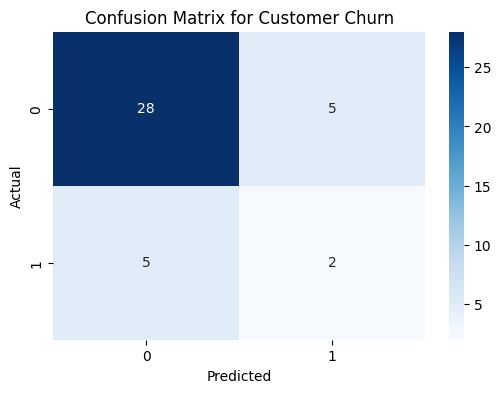

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Customer Churn")
plt.show()